# Cluster Analysis

The following tutorial contains Python examples for solving clustering problems. You should refer to Chapters 7 and 8 of the "Introduction to Data Mining" book, and slides week 5 to understand some of the concepts introduced in this tutorial.

Cluster analysis seeks to partition the input data into groups of closely related instances so that instances that belong to the same cluster are more similar to each other than to instances that belong to other clusters. 

In this tutorial, we will provide examples of using different clustering techniques provided by the scikit-learn library package. We will cover:
1. **K-means Clustering** (Partitional)
2. **Hierarchical Clustering** (Single, Complete, Average, and Ward's Method)
3. **Density-Based Clustering** (DBSCAN)
4. **Spectral Clustering** (Graph-based)

Read the step-by-step instructions below carefully. To execute the code, click on the corresponding cell and press the SHIFT-ENTER keys simultaneously.

In [1]:
import warnings
import os
warnings.filterwarnings("ignore") 
os.environ['LOKY_MAX_CPU_COUNT'] = '1' 

# Summary of toolbox

1. KMeans clustering. from sklearn.cluster import KMeans
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html 

2. Hierarchy clustering. from scipy.cluster import hierarchy
https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html

3. DBSCAN. from sklearn.cluster import DBSCAN
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html#sklearn.cluster.DBSCAN

4. SpectralClustering. from sklearn.cluster import SpectralClustering
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.SpectralClustering.html#sklearn.cluster.SpectralClustering 



## 1 K-means Clustering

The k-means clustering algorithm represents each cluster by its corresponding cluster centroid. The algorithm would partition the input data into *k* disjoint clusters by iteratively applying the following two steps:
1. Form *k* clusters by assigning each instance to its nearest centroid.
2. Recompute the centroid of each cluster.

In this section, we perform k-means clustering on a toy example of movie ratings dataset. We first create the dataset as follows.

In [2]:
import pandas as pd

ratings = [['john',5,5,2,1],['mary',4,5,3,2],['bob',4,4,4,3],['lisa',2,2,4,5],['lee',1,2,3,4],['harry',2,1,5,5]]
titles = ['user','Jaws','Star Wars','Exorcist','Omen']

#generate datafame: inlcuding user name and users' ratings of four movies
movies = pd.DataFrame(ratings,columns=titles) 

movies

,user,Jaws,Star Wars,Exorcist,Omen
0,john,5,5,2,1
1,mary,4,5,3,2
2,bob,4,4,4,3
3,lisa,2,2,4,5
4,lee,1,2,3,4
5,harry,2,1,5,5


In this example dataset, the first 3 users liked action movies (Jaws and Star Wars) while the last 3 users enjoyed horror movies (Exorcist and Omen). Our goal is to apply k-means clustering on the users to identify groups of users with similar movie preferences.

The example below shows how to apply k-means clustering (with k=2) on the movie ratings data. We must remove the "user" column first before applying the clustering algorithm. The cluster assignment for each user is displayed as a dataframe object.

In [3]:
from sklearn.cluster import KMeans

data = movies.drop('user',axis=1) # we only use the ratings as features, so the 'user' column is dropped.
k_means = KMeans(n_clusters=2, max_iter=50, random_state=1) # cluster the six users into two clusters.
# max_iter: Maximum number of iterations of the k-means algorithm for a single run.
k_means.fit(data)
labels = k_means.labels_
pd.DataFrame(labels, index=movies.user, columns=['Cluster ID'])

,Cluster ID
user,
john,0
mary,0
bob,0
lisa,1
lee,1
harry,1


The k-means clustering algorithm assigns the first three users to one cluster and the last three users to the second cluster. The results are consistent with our expectation. We can also display the centroid for each of the two clusters.

In [4]:
centroids = k_means.cluster_centers_
pd.DataFrame(centroids,columns=data.columns)

,Jaws,Star Wars,Exorcist,Omen
0,4.333333,4.666667,3.0,2.000000
1,1.666667,1.666667,4.0,4.666667


Observe that cluster 0 has higher ratings for the horror movies whereas cluster 1 has higher ratings for action movies. The cluster centroids can be applied to other users to determine their cluster assignments. 

In [5]:
import numpy as np

testData = np.array([[4,5,1,2],[3,2,4,4],[2,3,4,1],[3,2,3,3],[5,4,1,4]])
labels = k_means.predict(testData)
labels = labels.reshape(-1,1)
usernames = np.array(['paul','kim','liz','tom','bill']).reshape(-1,1)
cols = movies.columns.tolist()
cols.append('Cluster ID')
newusers = pd.DataFrame(np.concatenate((usernames, testData, labels), axis=1),columns=cols)
newusers

,user,Jaws,Star Wars,Exorcist,Omen,Cluster ID
0,paul,4,5,1,2,0
1,kim,3,2,4,4,1
2,liz,2,3,4,1,0
3,tom,3,2,3,3,1
4,bill,5,4,1,4,0


## 2 Hierarchical Clustering

This section demonstrates examples of applying hierarchical clustering to the `vertebrate.csv` . Specifically, we illustrate the results of using 4 hierarchical clustering algorithms provided by the Python scipy library: (1) single link (MIN), (2) complete link (MAX), (3) group average, and (4) Ward's method.  Other hierarchical clustering algorithms provided by the library include centroid-based.

In [6]:
import pandas as pd

data = pd.read_csv('vertebrate.csv',header='infer')
data

,Name,Warm-blooded,Gives Birth,Aquatic Creature,Aerial Creature,Has Legs,Hibernates,Class
0,human,1,1,0,0,1,0,mammals
1,python,0,0,0,0,0,1,reptiles
2,salmon,0,0,1,0,0,0,fishes
3,whale,1,1,1,0,0,0,mammals
4,frog,0,0,1,0,1,1,amphibians
5,komodo,0,0,0,0,1,0,reptiles
6,bat,1,1,0,1,1,1,mammals
7,pigeon,1,0,0,1,1,0,birds
8,cat,1,1,0,0,1,0,mammals
9,leopard shark,0,1,1,0,0,0,fishes


### 2.1 Single Link (MIN)

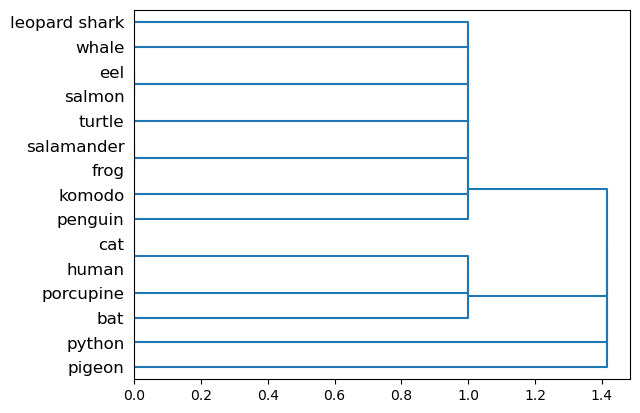

In [7]:
from scipy.cluster import hierarchy
import matplotlib.pyplot as plt
%matplotlib inline

names = data['Name']
Y = data['Class']
X = data.drop(['Name','Class'],axis=1)
Z = hierarchy.linkage(X.values, 'single') #hierarchy clusting using 'single' link
dn = hierarchy.dendrogram(Z,labels=names.tolist(),orientation='right') #plot dendrogram
plt.show()

### 2.2 Complete Link (MAX)

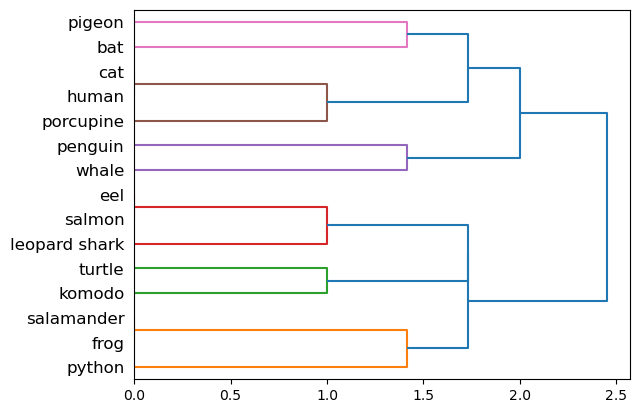

In [8]:
Z = hierarchy.linkage(X.values, 'complete') #change to 'complete' link
dn = hierarchy.dendrogram(Z,labels=names.tolist(),orientation='right')
plt.show()

### 2.3 Group Average

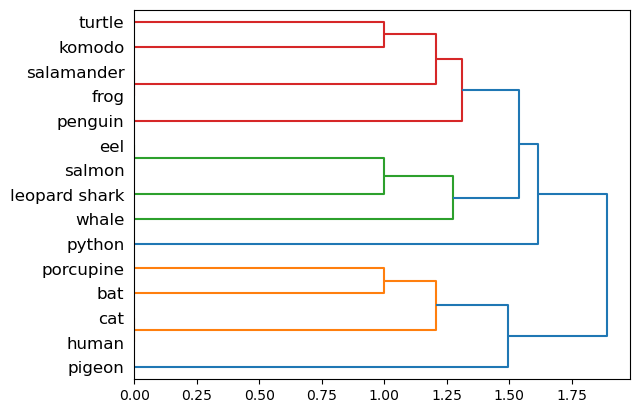

In [9]:
Z = hierarchy.linkage(X.values, 'average')
dn = hierarchy.dendrogram(Z,labels=names.tolist(),orientation='right')
plt.show()

### 2.4 Ward's Method (Minimum Variance)

Ward's method is another popular approach for hierarchical clustering, mentioned in the lecture slides. Unlike Single Link (MIN) or Complete Link (MAX), Ward's method minimizes the total within-cluster variance. At each step, it merges the pair of clusters that leads to the minimum increase in total within-cluster variance. This tends to produce clusters that are relatively equal in size and spherical in shape. It is implemented in `scipy` using `method='ward'`.

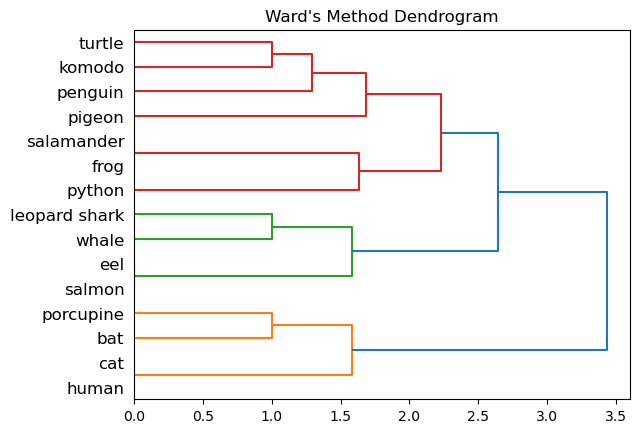

In [10]:
Z = hierarchy.linkage(X.values, 'ward') # Ward's method
dn = hierarchy.dendrogram(Z, labels=names.tolist(), orientation='right')
plt.title("Ward's Method Dendrogram")
plt.show()

### 2.5 Comparing Linkage Methods on Different Data Shapes

Reference Link: [Comparing different hierarchical linkage methods on toy datasets (scikit-learn)](https://scikit-learn.org/stable/auto_examples/cluster/plot_linkage_comparison.html)

Different linkage methods perform very differently depending on the geometry of your data. There is no single "best" algorithm.


We will compare:
*   **Single Link (MIN)**
*   **Complete Link (MAX)**
*   **Average Link**
*   **Ward's Method**

Run the code below to see how the same algorithm generates completely different results just by changing the data shape or the linkage method!

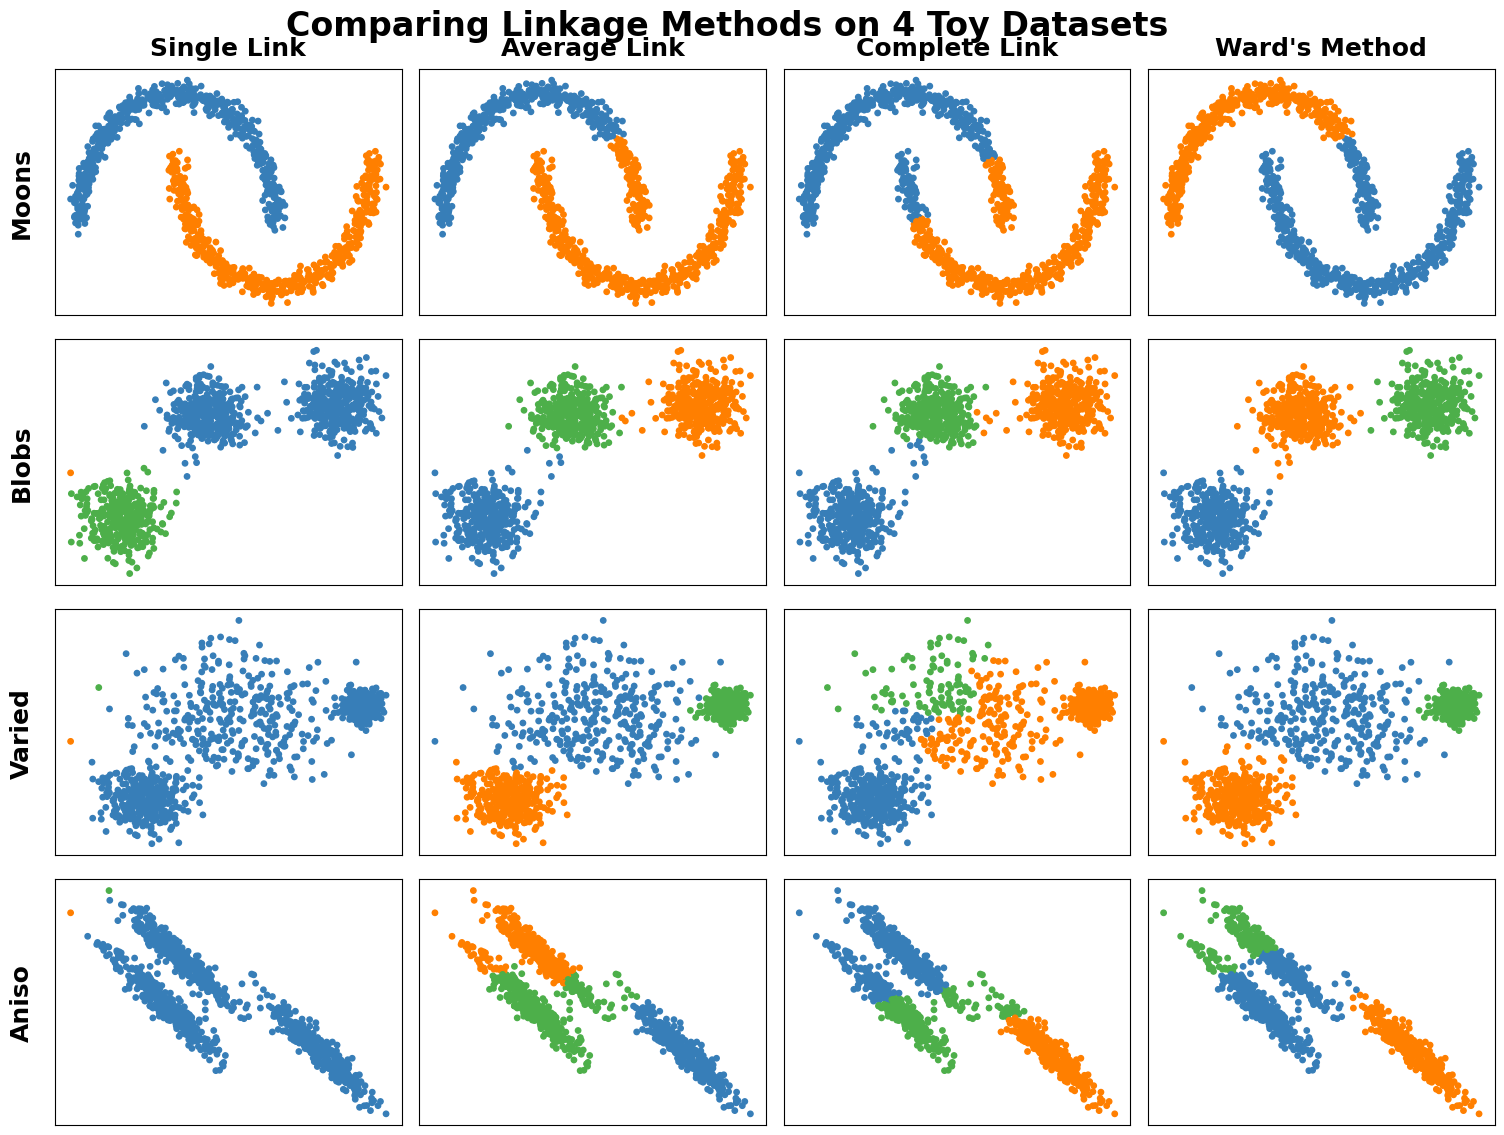

In [11]:
import warnings
from itertools import cycle, islice
import matplotlib.pyplot as plt
import numpy as np
from sklearn import cluster, datasets
from sklearn.preprocessing import StandardScaler

# 1. Generate 4 selected datasets
n_samples = 1000
moons = datasets.make_moons(n_samples=n_samples, noise=0.05, random_state=170)
blobs = datasets.make_blobs(n_samples=n_samples, random_state=170)
varied = datasets.make_blobs(n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=170)
X, _ = datasets.make_blobs(n_samples=n_samples, random_state=170)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X_aniso = np.dot(X, transformation)

datasets = [
    ("Moons", moons[0], 2),
    ("Blobs", blobs[0], 3),
    ("Varied", varied[0], 3),
    ("Aniso", X_aniso, 3)
]

# 2. Set up the plot
plt.figure(figsize=(16, 12))
plt.subplots_adjust(left=0.08, right=0.98, bottom=0.02, top=0.90, wspace=0.05, hspace=0.1)

plot_num = 1
algorithms = ["Single Link", "Average Link", "Complete Link", "Ward's Method"]

# 3. Loop through datasets and algorithms
for i, (name, X, n_clusters) in enumerate(datasets):
    X = StandardScaler().fit_transform(X)
    
    clustering_algorithms = (
        ("Single Link", cluster.AgglomerativeClustering(n_clusters=n_clusters, linkage="single")),
        ("Average Link", cluster.AgglomerativeClustering(n_clusters=n_clusters, linkage="average")),
        ("Complete Link", cluster.AgglomerativeClustering(n_clusters=n_clusters, linkage="complete")),
        ("Ward's Method", cluster.AgglomerativeClustering(n_clusters=n_clusters, linkage="ward")),
    )

    for j, (algo_name, algorithm) in enumerate(clustering_algorithms):
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore")
            algorithm.fit(X)
        
        y_pred = algorithm.labels_.astype(int)
        ax = plt.subplot(len(datasets), len(clustering_algorithms), plot_num)
        
        if i == 0:
            ax.set_title(algo_name, size=18, fontweight='bold', pad=10)
        if j == 0:
            ax.set_ylabel(name, size=18, fontweight='bold', labelpad=15)

        colors = np.array(list(islice(cycle(["#377eb8", "#ff7f00", "#4daf4a", "#f781bf"]), int(max(y_pred) + 1))))
        ax.scatter(X[:, 0], X[:, 1], s=15, color=colors[y_pred])
        ax.set_xticks(()); ax.set_yticks(())
        
        plot_num += 1

plt.suptitle("Comparing Linkage Methods on 4 Toy Datasets", fontsize=24, y=0.95, fontweight='bold')
plt.show()

## 3 Density-Based Clustering

Density-based clustering identifies the individual clusters as high-density regions that are separated by regions of low density. DBScan is one of the most popular density based clustering algorithms. In DBScan, data points are classified into 3 types---core points, border points, and noise points---based on the density of their local neighborhood. The local neighborhood density is defined according to 2 parameters:  radius of neighborhood size (eps) and minimum number of points in the neighborhood (min_samples). 

For this approach, we will use a noisy, 2-dimensional dataset originally created by Karypis et al. [1] for evaluating their proposed CHAMELEON algorithm. The example code shown below will load and plot the distribution of the data.

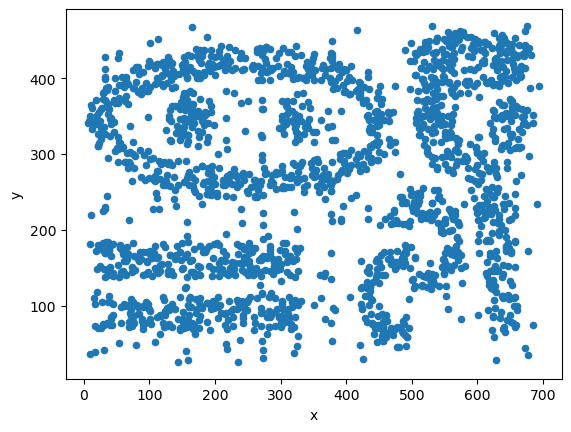

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

data = pd.read_csv('chameleon.data', delimiter=' ', names=['x','y'])
ax1=data.plot.scatter(x='x',y='y')
plt.show()

We apply the DBScan clustering algorithm on the data by setting the neighborhood radius (eps) to 15.5 and minimum number of points (min_samples) to be 5. The clusters are assigned to IDs between 0 to 8 while the noise points are assigned to a cluster ID equals to -1.

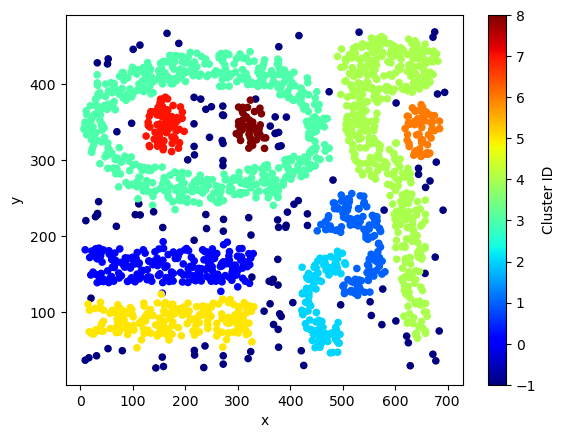

In [13]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=15.5, min_samples=5).fit(data)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = pd.DataFrame(db.labels_,columns=['Cluster ID'])
result = pd.concat((data,labels), axis=1)
ax1=result.plot.scatter(x='x',y='y',c='Cluster ID', colormap='jet')
plt.show()

## 4 Spectral Clustering

One of the main limitations of the k-means clustering algorithm is its tendency to seek for globular-shaped clusters. Thus, it does not work when applied to datasets with arbitrary-shaped clusters or when the cluster centroids overlapped with one another. Spectral clustering can overcome this limitation by exploiting properties of the similarity graph to overcome such limitations. To illustrate this, consider the following two-dimensional datasets.

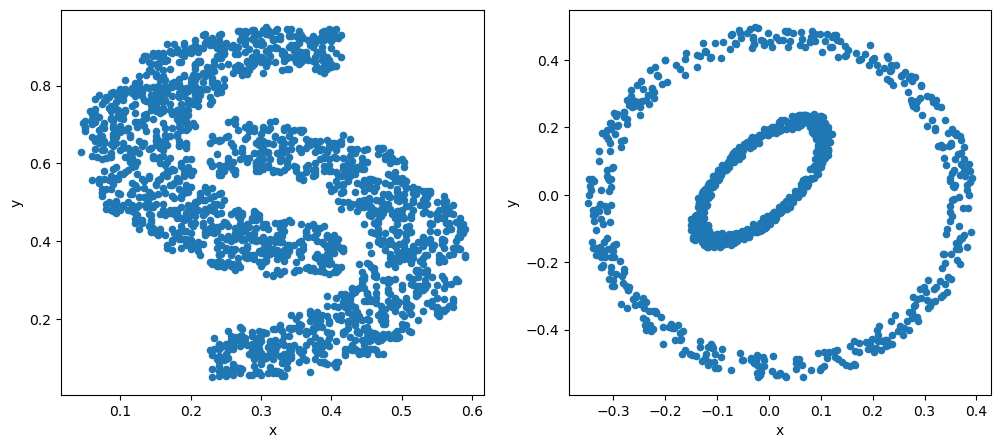

In [14]:
import pandas as pd

data1 = pd.read_csv('2d_data.txt', delimiter=' ', names=['x','y'])
data2 = pd.read_csv('elliptical.txt', delimiter=' ', names=['x','y'])

fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))
data1.plot.scatter(x='x',y='y',ax=ax1)
data2.plot.scatter(x='x',y='y',ax=ax2)
plt.show()

Below, we demonstrate the results of applying k-means to the datasets (with k=2).

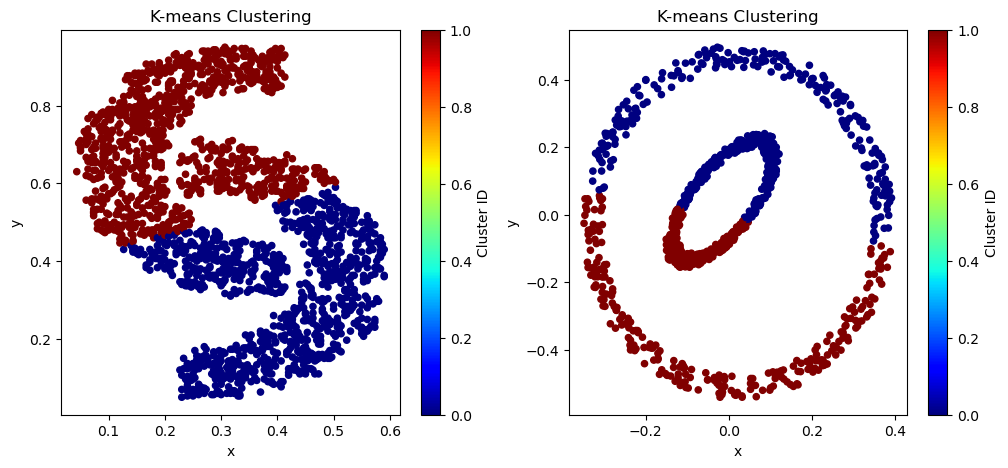

In [15]:
from sklearn import cluster

k_means = cluster.KMeans(n_clusters=2, max_iter=50, random_state=1)
k_means.fit(data1)
labels1 = pd.DataFrame(k_means.labels_,columns=['Cluster ID'])
result1 = pd.concat((data1,labels1), axis=1)

k_means2 = cluster.KMeans(n_clusters=2, max_iter=50, random_state=1)
k_means2.fit(data2)
labels2 = pd.DataFrame(k_means2.labels_,columns=['Cluster ID'])
result2 = pd.concat((data2,labels2), axis=1)

fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))
result1.plot.scatter(x='x',y='y',c='Cluster ID',colormap='jet',ax=ax1)
ax1.set_title('K-means Clustering')
result2.plot.scatter(x='x',y='y',c='Cluster ID',colormap='jet',ax=ax2)
ax2.set_title('K-means Clustering')
plt.show()

The plots above show the poor performance of k-means clustering. Next, we apply spectral clustering to the datasets. Spectral clustering converts the data into a similarity graph and applies the normalized cut graph partitioning algorithm to generate the clusters. In the example below, we use the Gaussian radial basis function as our affinity (similarity) measure. Users need to tune the kernel parameter (gamma) value in order to obtain the appropriate clusters for the given dataset. 

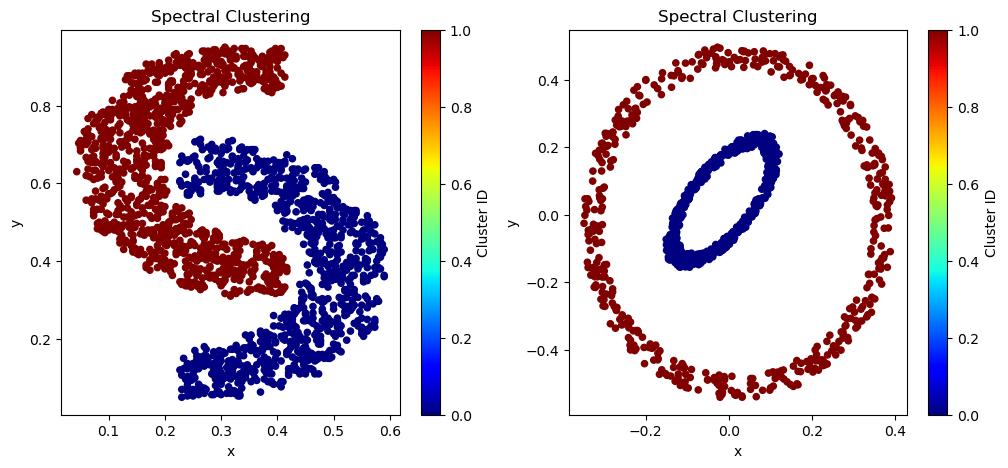

In [16]:
from sklearn.cluster import SpectralClustering
import pandas as pd

spectral = SpectralClustering(n_clusters=2,random_state=1,affinity='rbf',gamma=5000)
spectral.fit(data1)
labels1 = pd.DataFrame(spectral.labels_,columns=['Cluster ID'])
result1 = pd.concat((data1,labels1), axis=1)

spectral2 = SpectralClustering(n_clusters=2,random_state=1,affinity='rbf',gamma=500)
spectral2.fit(data2)
labels2 = pd.DataFrame(spectral2.labels_,columns=['Cluster ID'])
result2 = pd.concat((data2,labels2), axis=1)

fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))
result1.plot.scatter(x='x',y='y',c='Cluster ID',colormap='jet',ax=ax1)
ax1.set_title('Spectral Clustering')
result2.plot.scatter(x='x',y='y',c='Cluster ID',colormap='jet',ax=ax2)
ax2.set_title('Spectral Clustering')
plt.show()

## 5. Summary

This tutorial illustrates examples of using different Python's implementation of clustering algorithms. Algorithms such as k-means, spectral clustering, and DBScan are designed to create disjoint partitions of the data whereas the single-link, complete-link, and group average algorithms are designed to generate a hierarchy of cluster partitions.

References:
[1] George Karypis, Eui-Hong Han, and Vipin Kumar. CHAMELEON: A Hierarchical Clustering Algorithm Using Dynamic Modeling. IEEE Computer 32(8): 68-75, 1999.

# Week 5 assignment

### 1. Apply KMeans (K=3) to the **Iris dataset** (excluding the "class" attribute). Use 'petal width' and 'sepal length' to create a scatter plot and use cluster label as color. [10 points]

### 2. Apply BisectingKMeans (K=3) to the **Iris dataset** (excluding the "class" attribute). Briefly explain how its hierarchical partitioning mechanism differs from standard K-means. Reference link: [BisectingKMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.BisectingKMeans.html#sklearn.cluster.BisectingKMeans) [20 points]

### 3. Choose one density-based clustering algorithm and present the clustering results on the **Iris dataset** (excluding the "class" attribute). Tune its parameters and identify how many data points are classified as noise (-1). [20 points]

### 4. Based on the 4x4 grid plot in Section 2.5 of the tutorial (Moons, Blobs, Varied, Aniso), summarize which linkage method (Single, Average, Complete, or Ward's) is most suitable for which type of data shape, and state your final rule of thumb for selecting a linkage method. [20 points]

### 5. Review and compare different clustering algorithms and choose one clustering algorithm for your course project dataset. Reference link: [Clustering Algorithms](https://scikit-learn.org/stable/auto_examples/cluster/plot_cluster_comparison.html#sphx-glr-auto-examples-cluster-plot-cluster-comparison-py) [30 points]